# 10 - Ensemble PLR

This notebook combines the module-level PLR estimates from the statistical model notebooks.

The primary ensemble uses the two main seasonality-aware methods:

- multi-year Year-on-Year
- STL decomposition

SLR is retained as a baseline method and ARIMA is retained as a robustness check. Additional sensitivity ensembles are calculated to check whether the module-level interpretation changes when these supporting methods are included.

The main outputs are:

1. standardised PLR estimates from SLR, YoY, STL, and ARIMA
2. the primary YoY-STL ensemble PLR
3. sensitivity ensembles including SLR and/or ARIMA
4. method-comparison and ensemble figures
5. a final report table containing all method PLR estimates with confidence intervals and the primary ensemble PLR with confidence interval

## 1. Imports and plotting styles

In [41]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 200)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 11,
    "legend.title_fontsize": 11,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 12
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 11

## 2. Paths and constants


In [42]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

FINAL_FIG_DIR = PROJECT_ROOT / "figures" / "final figures"
FINAL_TABLE_DIR = PROJECT_ROOT / "tables" / "final tables"

DATA_PROCESSED_DIR = PROJECT_ROOT / "data_processed"
ENSEMBLE_OUTPUT_DIR = DATA_PROCESSED_DIR / "ensemble_outputs"

for folder in [FINAL_FIG_DIR, FINAL_TABLE_DIR, ENSEMBLE_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

MAIN_DATASET = "g200"
MAIN_METRIC = "PR_25C"

CONFIDENCE_LEVEL = 0.95
ALPHA = 1 - CONFIDENCE_LEVEL

N_MONTE_CARLO = 50000
MC_RANDOM_SEED = 3107

BLACK = "#111111"
GREY = "#BDBDBD"
LIGHT_GREY = "#E6E6E6"

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
    "Unknown": "#666666",
}

METHOD_COLORS = {
    "SLR": "#4D4D4D",
    "YoY": "#7B2CBF",
    "STL": "#D62839",
    "ARIMA": "#008B8B",
    "Primary ensemble": "#111111",
    "Baseline-extended ensemble": "#F4A261",
    "Robustness-extended ensemble": "#2A9D8F",
    "Full sensitivity ensemble": "#E76F51",
}

METHOD_MARKERS = {
    "SLR": "o",
    "YoY": "s",
    "STL": "^",
    "ARIMA": "v",
}

module_meta = pd.DataFrame({
    "Module_ID": list(range(1, 11)),
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))

print("Project root:", PROJECT_ROOT)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)
print("Ensemble data folder:", ENSEMBLE_OUTPUT_DIR)

Project root: C:\Users\amina\Thesis\Final Pipeline
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables
Ensemble data folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\ensemble_outputs


In [43]:
CANDIDATE_METHOD_PATHS = {
    "SLR": [
        FINAL_TABLE_DIR / "slr_for_ensemble.csv",
        FINAL_TABLE_DIR / "slr_plr_estimates_all_datasets.csv",
        FINAL_TABLE_DIR / "slr_plr_summary_all_datasets.csv",
        PROJECT_ROOT / "results" / "statistical_models" / "slr" / "tables" / "slr_plr_summary_all_datasets.csv",
    ],
    "YoY": [
        FINAL_TABLE_DIR / "yoy_for_ensemble.csv",
        FINAL_TABLE_DIR / "yoy_plr_estimates_all_datasets.csv",
        FINAL_TABLE_DIR / "yoy_plr_summary_all_datasets.csv",
        PROJECT_ROOT / "tables" / "final tables" / "multi_year_yoy_plr_estimates_g200.csv",
    ],
    "STL": [
        DATA_PROCESSED_DIR / "stl_outputs" / "stl_for_ensemble.parquet",
        FINAL_TABLE_DIR / "stl_for_ensemble.csv",
        FINAL_TABLE_DIR / "stl_plr_estimates_all_datasets.csv",
        PROJECT_ROOT / "results" / "statistical_models" / "stl" / "data" / "stl_for_ensemble.parquet",
        PROJECT_ROOT / "results" / "statistical_models" / "stl" / "tables" / "stl_all_results.csv",
    ],
    "ARIMA": [
        DATA_PROCESSED_DIR / "arima_outputs" / "arima_for_ensemble.parquet",
        FINAL_TABLE_DIR / "arima_for_ensemble.csv",
        FINAL_TABLE_DIR / "arima_plr_estimates_all_datasets.csv",
        PROJECT_ROOT / "results" / "statistical_models" / "arima" / "data" / "arima_for_ensemble.parquet",
        PROJECT_ROOT / "results" / "statistical_models" / "arima" / "tables" / "arima_all_results.csv",
    ],
}


def find_existing_path(paths):
    """
    Return the first existing path from a list of candidate paths.
    """
    for path in paths:
        if path.exists():
            return path

    return None


selected_method_paths = {}

for method_name, paths in CANDIDATE_METHOD_PATHS.items():
    selected_path = find_existing_path(paths)
    selected_method_paths[method_name] = selected_path

    print(f"{method_name}: {selected_path}")

missing_methods = [
    method_name
    for method_name, path in selected_method_paths.items()
    if path is None
]

if missing_methods:
    raise FileNotFoundError(
        f"No input result file found for these methods: {missing_methods}"
    )

SLR: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\slr_plr_summary_all_datasets.csv
YoY: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\multi_year_yoy_plr_estimates_g200.csv
STL: C:\Users\amina\Thesis\Final Pipeline\data_processed\stl_outputs\stl_for_ensemble.parquet
ARIMA: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs\arima_for_ensemble.parquet


## 3. Helper functions

In [44]:
def save_fig(filename, fig=None):
    """
    Save figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def load_result_file(path):
    """
    Load a CSV or parquet result file.
    """
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)

    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)

    raise ValueError(f"Unsupported file type: {path}")


def normalise_type_label(value):
    """
    Normalise module category labels across result files.
    """
    if pd.isna(value):
        return "Unknown"

    value_str = str(value).strip()

    if value_str in TYPE_COLORS:
        return value_str

    value_low = value_str.lower()

    if "pid" in value_low:
        return "PID/Reference"
    if "ucrack" in value_low or "microcrack" in value_low or "crack" in value_low:
        return "uCrack"
    if "ref" in value_low:
        return "Reference"

    return "Unknown"


def first_existing_column(df, candidates, required=True):
    """
    Return the first existing column name from a candidate list.
    """
    for col in candidates:
        if col in df.columns:
            return col

    if required:
        raise ValueError(f"None of these columns were found: {candidates}")

    return None


def ci_to_se(ci_low, ci_high):
    """
    Approximate standard error from a 95% confidence interval.

    SE ≈ (upper - lower) / (2 * 1.96)
    """
    return (ci_high - ci_low) / (2 * 1.96)


def module_category_legend_handles():
    """
    Legend handles for module categories.
    """
    return [
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="Reference",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["uCrack"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="uCrack",
        ),
        Line2D(
            [0], [0],
            marker="o",
            linestyle="none",
            markersize=7,
            markerfacecolor=TYPE_COLORS["PID/Reference"],
            markeredgecolor=BLACK,
            markeredgewidth=0.7,
            label="PID/Reference",
        ),
    ]


def format_plr_ci_text(row, value_col, low_col, high_col, digits=3):
    """
    Format PLR estimate and confidence interval for report tables.
    """
    if pd.isna(row[value_col]):
        return ""

    return (
        f"{row[value_col]:.{digits}f} "
        f"[{row[low_col]:.{digits}f}, {row[high_col]:.{digits}f}]"
    )

## 4. Load and standardise method outputs

In [45]:
METHOD_ROLES = {
    "SLR": "Baseline",
    "YoY": "Primary",
    "STL": "Primary",
    "ARIMA": "Robustness check",
}

METHOD_AGGREGATION = {
    "SLR": "Monthly",
    "YoY": "Daily multi-year pairs",
    "STL": "Monthly",
    "ARIMA": "Monthly",
}

PLR_COLUMN_CANDIDATES = {
    "SLR": [
        "PLR_pct_per_year",
        "PLR_SLR_pct_per_year",
        "PLR_SLR",
    ],
    "YoY": [
        "PLR_pct_per_year",
        "PLR_YoY_pct_per_year",
        "PLR_YoY",
    ],
    "STL": [
        "PLR_pct_per_year",
        "PLR_STL_pct_per_year",
        "PLR_STL",
    ],
    "ARIMA": [
        "PLR_pct_per_year",
        "PLR_ARIMA_pct_per_year",
        "PLR_ARIMA",
    ],
}

CI_LOW_COLUMN_CANDIDATES = {
    "SLR": [
        "PLR_ci_low",
        "PLR_SLR_ci_low",
        "PLR_SLR_ci_low_pct_per_year",
    ],
    "YoY": [
        "PLR_ci_low",
        "PLR_YoY_ci_low",
        "PLR_YoY_ci_low_pct_per_year",
    ],
    "STL": [
        "PLR_ci_low",
        "PLR_STL_ci_low",
        "PLR_STL_ci_low_pct_per_year",
    ],
    "ARIMA": [
        "PLR_ci_low",
        "PLR_ARIMA_ci_low",
        "PLR_ARIMA_ci_low_pct_per_year",
    ],
}

CI_HIGH_COLUMN_CANDIDATES = {
    "SLR": [
        "PLR_ci_high",
        "PLR_SLR_ci_high",
        "PLR_SLR_ci_high_pct_per_year",
    ],
    "YoY": [
        "PLR_ci_high",
        "PLR_YoY_ci_high",
        "PLR_YoY_ci_high_pct_per_year",
    ],
    "STL": [
        "PLR_ci_high",
        "PLR_STL_ci_high",
        "PLR_STL_ci_high_pct_per_year",
    ],
    "ARIMA": [
        "PLR_ci_high",
        "PLR_ARIMA_ci_high",
        "PLR_ARIMA_ci_high_pct_per_year",
    ],
}

SE_COLUMN_CANDIDATES = {
    "SLR": [
        "PLR_se",
        "PLR_SLR_se",
        "PLR_SLR_se_pct_per_year",
    ],
    "YoY": [
        "PLR_se",
        "PLR_YoY_bootstrap_se_pct_per_year",
        "PLR_YoY_se",
        "PLR_YoY_se_pct_per_year",
    ],
    "STL": [
        "PLR_se",
        "PLR_STL_se",
        "PLR_STL_se_pct_per_year",
    ],
    "ARIMA": [
        "PLR_se",
        "PLR_ARIMA_se",
        "PLR_ARIMA_se_pct_per_year",
    ],
}

In [46]:
def standardise_method_output(method_name, path):
    """
    Load and standardise one method result table.
    """
    raw = load_result_file(path).copy()

    module_col = first_existing_column(raw, ["Module_ID", "Module", "module_id"])
    dataset_col = first_existing_column(raw, ["dataset", "Dataset"], required=False)
    type_col = first_existing_column(raw, ["Type", "Module category", "module_type"], required=False)

    plr_col = first_existing_column(raw, PLR_COLUMN_CANDIDATES[method_name])
    ci_low_col = first_existing_column(raw, CI_LOW_COLUMN_CANDIDATES[method_name])
    ci_high_col = first_existing_column(raw, CI_HIGH_COLUMN_CANDIDATES[method_name])
    se_col = first_existing_column(raw, SE_COLUMN_CANDIDATES[method_name], required=False)

    standard = pd.DataFrame({
        "method": method_name,
        "method_role": METHOD_ROLES[method_name],
        "dataset": raw[dataset_col] if dataset_col is not None else MAIN_DATASET,
        "Module_ID": raw[module_col].astype(int),
        "Type": raw[type_col] if type_col is not None else raw[module_col].map(MODULE_TYPE_MAP),
        "metric": MAIN_METRIC,
        "aggregation": METHOD_AGGREGATION[method_name],
        "PLR_pct_per_year": raw[plr_col].astype(float),
        "PLR_ci_low": raw[ci_low_col].astype(float),
        "PLR_ci_high": raw[ci_high_col].astype(float),
    })

    ci_low_ordered = standard[["PLR_ci_low", "PLR_ci_high"]].min(axis=1)
    ci_high_ordered = standard[["PLR_ci_low", "PLR_ci_high"]].max(axis=1)

    standard["PLR_ci_low"] = ci_low_ordered
    standard["PLR_ci_high"] = ci_high_ordered

    standard["PLR_se"] = ci_to_se(
        standard["PLR_ci_low"],
        standard["PLR_ci_high"],
    )

    standard["dataset"] = standard["dataset"].astype(str).str.strip().str.lower()
    standard["Type"] = standard["Type"].apply(normalise_type_label)

    standard = (
        standard
        .sort_values(["dataset", "Module_ID"])
        .drop_duplicates(subset=["method", "dataset", "Module_ID"], keep="first")
        .reset_index(drop=True)
    )

    return standard


method_tables = []

for method_name, path in selected_method_paths.items():
    method_standard = standardise_method_output(method_name, path)
    method_tables.append(method_standard)

    print(f"{method_name} standardised")
    print("Input:", path)
    print("Shape:", method_standard.shape)
    print("Datasets:", sorted(method_standard["dataset"].unique()))
    print("-" * 80)

method_results = (
    pd.concat(method_tables, ignore_index=True)
    .sort_values(["dataset", "Module_ID", "method"])
    .reset_index(drop=True)
)

method_results["is_main_dataset"] = method_results["dataset"].eq(MAIN_DATASET)

display(method_results.head(20))

SLR standardised
Input: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\slr_plr_summary_all_datasets.csv
Shape: (30, 11)
Datasets: ['g200', 'g400', 'sunny']
--------------------------------------------------------------------------------
YoY standardised
Input: C:\Users\amina\Thesis\Final Pipeline\tables\final tables\multi_year_yoy_plr_estimates_g200.csv
Shape: (10, 11)
Datasets: ['g200']
--------------------------------------------------------------------------------
STL standardised
Input: C:\Users\amina\Thesis\Final Pipeline\data_processed\stl_outputs\stl_for_ensemble.parquet
Shape: (20, 11)
Datasets: ['g200', 'g400']
--------------------------------------------------------------------------------
ARIMA standardised
Input: C:\Users\amina\Thesis\Final Pipeline\data_processed\arima_outputs\arima_for_ensemble.parquet
Shape: (20, 11)
Datasets: ['g200', 'g400']
--------------------------------------------------------------------------------


,method,method_role,dataset,Module_ID,Type,metric,aggregation,PLR_pct_per_year,PLR_ci_low,PLR_ci_high,PLR_se,is_main_dataset
0,ARIMA,Robustness check,g200,1,PID/Reference,PR_25C,Monthly,-0.368709,-0.466360,-0.271057,0.049822,True
1,SLR,Baseline,g200,1,PID/Reference,PR_25C,Monthly,-0.377533,-0.599957,-0.155109,0.113482,True
2,STL,Primary,g200,1,PID/Reference,PR_25C,Monthly,-0.371689,-0.458705,-0.284673,0.044396,True
3,YoY,Primary,g200,1,PID/Reference,PR_25C,Daily multi-year pairs,-0.333248,-0.412784,-0.280843,0.033658,True
4,ARIMA,Robustness check,g200,2,Reference,PR_25C,Monthly,-0.102688,-0.702185,0.496808,0.305865,True
5,SLR,Baseline,g200,2,Reference,PR_25C,Monthly,-0.295753,-0.553917,-0.037590,0.131716,True
6,STL,Primary,g200,2,Reference,PR_25C,Monthly,-0.199528,-0.284839,-0.114218,0.043526,True
7,YoY,Primary,g200,2,Reference,PR_25C,Daily multi-year pairs,-0.359134,-0.415543,-0.303774,0.028513,True
8,ARIMA,Robustness check,g200,3,uCrack,PR_25C,Monthly,0.339654,-1.299834,1.979142,0.836474,True
9,SLR,Baseline,g200,3,uCrack,PR_25C,Monthly,0.006091,-0.514413,0.526595,0.265563,True


## 5. Method support summary

This table checks which methods are available for each dataset and module.

In [47]:
method_support_summary = (
    method_results
    .groupby(["dataset", "method", "method_role"], as_index=False)
    .agg(
        n_modules=("Module_ID", "nunique"),
        min_PLR=("PLR_pct_per_year", "min"),
        median_PLR=("PLR_pct_per_year", "median"),
        max_PLR=("PLR_pct_per_year", "max"),
        median_SE=("PLR_se", "median"),
    )
    .sort_values(["dataset", "method"])
    .reset_index(drop=True)
)

display(method_support_summary)

method_support_summary.to_csv(
    FINAL_TABLE_DIR / "ensemble_method_support_summary.csv",
    index=False,
)

,dataset,method,method_role,n_modules,min_PLR,median_PLR,max_PLR,median_SE
0,g200,ARIMA,Robustness check,10,-1.671927,-0.344757,0.339654,0.366038
1,g200,SLR,Baseline,10,-1.452835,-0.391578,0.006091,0.147283
2,g200,STL,Primary,10,-1.703723,-0.289802,0.065959,0.086630
3,g200,YoY,Primary,10,-1.494343,-0.434149,0.039615,0.039640
4,g400,ARIMA,Robustness check,10,-1.531851,-0.588627,0.314140,0.291198
5,g400,SLR,Baseline,10,-1.213175,-0.392412,0.002006,0.131049
6,g400,STL,Primary,10,-1.325074,-0.238022,0.341502,0.080372
7,sunny,SLR,Baseline,10,-0.964782,-0.452951,0.102160,0.175419


In [48]:
main_method_matrix = (
    method_results
    .loc[method_results["dataset"] == MAIN_DATASET]
    .pivot_table(
        index=["Module_ID", "Type"],
        columns="method",
        values="PLR_pct_per_year",
        aggfunc="first",
    )
    .reset_index()
)

required_primary_methods = ["YoY", "STL"]

main_method_matrix["has_primary_ensemble_support"] = (
    main_method_matrix[required_primary_methods]
    .notna()
    .all(axis=1)
)

display(main_method_matrix)

missing_primary = main_method_matrix.loc[
    ~main_method_matrix["has_primary_ensemble_support"],
    ["Module_ID", "Type"] + required_primary_methods,
]

if not missing_primary.empty:
    display(missing_primary)
    raise ValueError("At least one module is missing YoY or STL support for the primary ensemble.")

print("All modules have YoY and STL results for the primary ensemble.")

method,Module_ID,Type,ARIMA,SLR,STL,YoY,has_primary_ensemble_support
0,1,PID/Reference,-0.368709,-0.377533,-0.371689,-0.333248,True
1,2,Reference,-0.102688,-0.295753,-0.199528,-0.359134,True
2,3,uCrack,0.339654,0.006091,0.065959,0.039615,True
3,4,uCrack,-0.250568,-0.365315,-0.189276,-0.459581,True
4,5,Reference,-0.252889,-0.314549,-0.154026,-0.399898,True
5,6,uCrack,-0.320805,-0.405623,-0.207915,-0.408718,True
6,7,uCrack,-0.693458,-0.621814,-0.489180,-0.630290,True
7,8,uCrack,-1.084372,-0.867885,-0.813982,-0.938799,True
8,9,uCrack,-1.671927,-1.452835,-1.703723,-1.494343,True
9,10,Reference,-1.595494,-1.287079,-1.404105,-1.272990,True


All modules have YoY and STL results for the primary ensemble.


## 6. Define ensembles

The primary ensemble combines YoY and STL. Sensitivity ensembles are calculated to check whether the headline result changes when the baseline SLR method or the ARIMA robustness-check method is included.

In [49]:
ENSEMBLE_DEFINITIONS = {
    "Primary ensemble": {
        "methods": ["YoY", "STL"],
        "role": "Main result",
        "description": "YoY + STL",
    },
    "Baseline-extended ensemble": {
        "methods": ["SLR", "YoY", "STL"],
        "role": "Sensitivity",
        "description": "SLR + YoY + STL",
    },
    "Robustness-extended ensemble": {
        "methods": ["YoY", "STL", "ARIMA"],
        "role": "Sensitivity",
        "description": "YoY + STL + ARIMA",
    },
    "Full sensitivity ensemble": {
        "methods": ["SLR", "YoY", "STL", "ARIMA"],
        "role": "Sensitivity",
        "description": "SLR + YoY + STL + ARIMA",
    },
}

ensemble_definition_table = pd.DataFrame([
    {
        "Ensemble": ensemble_name,
        "Role": spec["role"],
        "Methods": ", ".join(spec["methods"]),
        "Description": spec["description"],
        "Number of methods": len(spec["methods"]),
    }
    for ensemble_name, spec in ENSEMBLE_DEFINITIONS.items()
])

display(ensemble_definition_table)

ensemble_definition_table.to_csv(
    FINAL_TABLE_DIR / "ensemble_definitions.csv",
    index=False,
)

,Ensemble,Role,Methods,Description,Number of methods
0,Primary ensemble,Main result,"YoY, STL",YoY + STL,2
1,Baseline-extended ensemble,Sensitivity,"SLR, YoY, STL",SLR + YoY + STL,3
2,Robustness-extended ensemble,Sensitivity,"YoY, STL, ARIMA",YoY + STL + ARIMA,3
3,Full sensitivity ensemble,Sensitivity,"SLR, YoY, STL, ARIMA",SLR + YoY + STL + ARIMA,4


## 7. Calculate ensembles

For each module, each method-specific PLR estimate is represented as a normal distribution using its reported estimate and standard error. Monte Carlo sampling is used to propagate method-level uncertainty into the ensemble confidence interval.

The deterministic ensemble point estimate is calculated as the mean of the method point estimates.

In [50]:
def calculate_ensemble_for_module(
    method_df,
    dataset_name,
    module_id,
    ensemble_name,
    ensemble_methods,
    n_samples=N_MONTE_CARLO,
    random_seed=MC_RANDOM_SEED,
):
    """
    Calculate one module-level ensemble PLR estimate.
    """
    module_method_df = (
        method_df
        .loc[
            (method_df["dataset"] == dataset_name)
            & (method_df["Module_ID"] == module_id)
            & (method_df["method"].isin(ensemble_methods))
        ]
        .copy()
        .sort_values("method")
    )

    available_methods = sorted(module_method_df["method"].unique())
    missing_methods = sorted(set(ensemble_methods) - set(available_methods))

    module_type = (
        method_df
        .loc[
            (method_df["dataset"] == dataset_name)
            & (method_df["Module_ID"] == module_id),
            "Type",
        ]
        .dropna()
        .iloc[0]
    )

    result_base = {
        "dataset": dataset_name,
        "Module_ID": int(module_id),
        "Type": module_type,
        "ensemble": ensemble_name,
        "ensemble_role": ENSEMBLE_DEFINITIONS[ensemble_name]["role"],
        "ensemble_description": ENSEMBLE_DEFINITIONS[ensemble_name]["description"],
        "methods_requested": ", ".join(ensemble_methods),
        "methods_available": ", ".join(available_methods),
        "missing_methods": ", ".join(missing_methods),
        "n_methods_requested": len(ensemble_methods),
        "n_methods_available": len(available_methods),
        "has_required_methods": len(missing_methods) == 0,
    }

    if len(missing_methods) > 0:
        return {
            **result_base,
            "PLR_ensemble_pct_per_year": np.nan,
            "PLR_ensemble_mc_mean": np.nan,
            "PLR_ensemble_mc_median": np.nan,
            "PLR_ensemble_se": np.nan,
            "PLR_ensemble_ci_low": np.nan,
            "PLR_ensemble_ci_high": np.nan,
            "ci_crosses_zero": np.nan,
            "method_min_PLR": np.nan,
            "method_max_PLR": np.nan,
            "method_range_PLR": np.nan,
            "method_std_PLR": np.nan,
        }

    values = module_method_df["PLR_pct_per_year"].astype(float).to_numpy()
    ses = module_method_df["PLR_se"].astype(float).to_numpy()

    if np.any(~np.isfinite(ses)) or np.any(ses <= 0):
        raise ValueError(
            f"Invalid PLR_se for {dataset_name}, Module {module_id}, {ensemble_name}."
        )

    ensemble_point = np.mean(values)

    seed_offset = int(module_id) * 1000 + sum(
        ord(char) for char in f"{dataset_name}_{ensemble_name}"
    )

    rng = np.random.default_rng(random_seed + seed_offset)

    draws = rng.normal(
        loc=values,
        scale=ses,
        size=(n_samples, len(values)),
    )

    ensemble_draws = draws.mean(axis=1)

    ci_low = np.percentile(ensemble_draws, 100 * ALPHA / 2)
    ci_high = np.percentile(ensemble_draws, 100 * (1 - ALPHA / 2))

    return {
        **result_base,
        "PLR_ensemble_pct_per_year": ensemble_point,
        "PLR_ensemble_mc_mean": np.mean(ensemble_draws),
        "PLR_ensemble_mc_median": np.median(ensemble_draws),
        "PLR_ensemble_se": np.std(ensemble_draws, ddof=1),
        "PLR_ensemble_ci_low": ci_low,
        "PLR_ensemble_ci_high": ci_high,
        "ci_crosses_zero": ci_low <= 0 <= ci_high,
        "method_min_PLR": np.min(values),
        "method_max_PLR": np.max(values),
        "method_range_PLR": np.max(values) - np.min(values),
        "method_std_PLR": np.std(values, ddof=1) if len(values) > 1 else 0,
    }

In [51]:
ensemble_rows = []

datasets_to_evaluate = sorted(method_results["dataset"].unique())

for dataset_name in datasets_to_evaluate:
    dataset_modules = sorted(
        method_results
        .loc[method_results["dataset"] == dataset_name, "Module_ID"]
        .dropna()
        .unique()
    )

    print(f"Calculating ensembles for dataset: {dataset_name}")

    for module_id in dataset_modules:
        for ensemble_name, spec in ENSEMBLE_DEFINITIONS.items():
            result = calculate_ensemble_for_module(
                method_df=method_results,
                dataset_name=dataset_name,
                module_id=int(module_id),
                ensemble_name=ensemble_name,
                ensemble_methods=spec["methods"],
            )

            ensemble_rows.append(result)

    print("-" * 80)

ensemble_results = (
    pd.DataFrame(ensemble_rows)
    .sort_values(["dataset", "Module_ID", "ensemble"])
    .reset_index(drop=True)
)

display(ensemble_results.head(20))

Calculating ensembles for dataset: g200
--------------------------------------------------------------------------------
Calculating ensembles for dataset: g400
--------------------------------------------------------------------------------
Calculating ensembles for dataset: sunny
--------------------------------------------------------------------------------


,dataset,Module_ID,Type,ensemble,ensemble_role,ensemble_description,methods_requested,methods_available,missing_methods,n_methods_requested,n_methods_available,has_required_methods,PLR_ensemble_pct_per_year,PLR_ensemble_mc_mean,PLR_ensemble_mc_median,PLR_ensemble_se,PLR_ensemble_ci_low,PLR_ensemble_ci_high,ci_crosses_zero,method_min_PLR,method_max_PLR,method_range_PLR,method_std_PLR
0,g200,1,PID/Reference,Baseline-extended ensemble,Sensitivity,SLR + YoY + STL,"SLR, YoY, STL","SLR, STL, YoY",,3,3,True,-0.360823,-0.360877,-0.360883,0.042054,-0.443398,-0.278399,False,-0.377533,-0.333248,0.044285,0.024059
1,g200,1,PID/Reference,Full sensitivity ensemble,Sensitivity,SLR + YoY + STL + ARIMA,"SLR, YoY, STL, ARIMA","ARIMA, SLR, STL, YoY",,4,4,True,-0.362795,-0.363050,-0.362788,0.033954,-0.430013,-0.296772,False,-0.377533,-0.333248,0.044285,0.020036
2,g200,1,PID/Reference,Primary ensemble,Main result,YoY + STL,"YoY, STL","STL, YoY",,2,2,True,-0.352468,-0.352226,-0.352213,0.027816,-0.407083,-0.297709,False,-0.371689,-0.333248,0.038441,0.027182
3,g200,1,PID/Reference,Robustness-extended ensemble,Sensitivity,YoY + STL + ARIMA,"YoY, STL, ARIMA","ARIMA, STL, YoY",,3,3,True,-0.357882,-0.357797,-0.357802,0.024905,-0.406294,-0.309010,False,-0.371689,-0.333248,0.038441,0.021385
4,g200,2,Reference,Baseline-extended ensemble,Sensitivity,SLR + YoY + STL,"SLR, YoY, STL","SLR, STL, YoY",,3,3,True,-0.284805,-0.284834,-0.284843,0.046952,-0.376993,-0.193276,False,-0.359134,-0.199528,0.159605,0.080364
5,g200,2,Reference,Full sensitivity ensemble,Sensitivity,SLR + YoY + STL + ARIMA,"SLR, YoY, STL, ARIMA","ARIMA, SLR, STL, YoY",,4,4,True,-0.239276,-0.238874,-0.238440,0.084096,-0.405035,-0.074829,False,-0.359134,-0.102688,0.256445,0.112237
6,g200,2,Reference,Primary ensemble,Main result,YoY + STL,"YoY, STL","STL, YoY",,2,2,True,-0.279331,-0.279178,-0.279012,0.025957,-0.330197,-0.228567,False,-0.359134,-0.199528,0.159605,0.112858
7,g200,2,Reference,Robustness-extended ensemble,Sensitivity,YoY + STL + ARIMA,"YoY, STL, ARIMA","ARIMA, STL, YoY",,3,3,True,-0.220450,-0.221266,-0.221036,0.103026,-0.423139,-0.020116,False,-0.359134,-0.102688,0.256445,0.129497
8,g200,3,uCrack,Baseline-extended ensemble,Sensitivity,SLR + YoY + STL,"SLR, YoY, STL","SLR, STL, YoY",,3,3,True,0.037222,0.037636,0.036797,0.104805,-0.167983,0.242531,True,0.006091,0.065959,0.059868,0.030006
9,g200,3,uCrack,Full sensitivity ensemble,Sensitivity,SLR + YoY + STL + ARIMA,"SLR, YoY, STL, ARIMA","ARIMA, SLR, STL, YoY",,4,4,True,0.112830,0.112679,0.112867,0.222810,-0.324598,0.549303,True,0.006091,0.339654,0.333563,0.153188


## 8. Primary ensemble result

The main PLR result is the primary YoY-STL ensemble for the g200 dataset.

In [52]:
primary_ensemble_main = (
    ensemble_results
    .loc[
        (ensemble_results["dataset"] == MAIN_DATASET)
        & (ensemble_results["ensemble"] == "Primary ensemble")
        & (ensemble_results["has_required_methods"])
    ]
    .copy()
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

primary_ensemble_main["Primary ensemble PLR [95% CI]"] = primary_ensemble_main.apply(
    lambda r: format_plr_ci_text(
        r,
        "PLR_ensemble_pct_per_year",
        "PLR_ensemble_ci_low",
        "PLR_ensemble_ci_high",
    ),
    axis=1,
)

primary_ensemble_main["loss_rank"] = (
    primary_ensemble_main["PLR_ensemble_pct_per_year"]
    .rank(method="dense", ascending=True)
    .astype(int)
)

display(
    primary_ensemble_main[
        [
            "Module_ID",
            "Type",
            "methods_available",
            "PLR_ensemble_pct_per_year",
            "PLR_ensemble_ci_low",
            "PLR_ensemble_ci_high",
            "Primary ensemble PLR [95% CI]",
            "PLR_ensemble_se",
            "method_range_PLR",
            "ci_crosses_zero",
            "loss_rank",
        ]
    ]
)

,Module_ID,Type,methods_available,PLR_ensemble_pct_per_year,PLR_ensemble_ci_low,PLR_ensemble_ci_high,Primary ensemble PLR [95% CI],PLR_ensemble_se,method_range_PLR,ci_crosses_zero,loss_rank
0,1,PID/Reference,"STL, YoY",-0.352468,-0.407083,-0.297709,"-0.352 [-0.407, -0.298]",0.027816,0.038441,False,5
1,2,Reference,"STL, YoY",-0.279331,-0.330197,-0.228567,"-0.279 [-0.330, -0.229]",0.025957,0.159605,False,8
2,3,uCrack,"STL, YoY",0.052787,-0.114235,0.217578,"0.053 [-0.114, 0.218]",0.084912,0.026344,True,10
3,4,uCrack,"STL, YoY",-0.324428,-0.399178,-0.249417,"-0.324 [-0.399, -0.249]",0.038243,0.270305,False,6
4,5,Reference,"STL, YoY",-0.276962,-0.356707,-0.197259,"-0.277 [-0.357, -0.197]",0.040890,0.245872,False,9
5,6,uCrack,"STL, YoY",-0.308316,-0.398468,-0.218367,"-0.308 [-0.398, -0.218]",0.045914,0.200803,False,7
6,7,uCrack,"STL, YoY",-0.559735,-0.676121,-0.445730,"-0.560 [-0.676, -0.446]",0.058940,0.141110,False,4
7,8,uCrack,"STL, YoY",-0.876391,-0.974906,-0.777043,"-0.876 [-0.975, -0.777]",0.050431,0.124816,False,3
8,9,uCrack,"STL, YoY",-1.599033,-1.764586,-1.432584,"-1.599 [-1.765, -1.433]",0.084608,0.209380,False,1
9,10,Reference,"STL, YoY",-1.338547,-1.526298,-1.148364,"-1.339 [-1.526, -1.148]",0.096259,0.131115,False,2


## 9. Final method and ensemble table

This table contains the method-specific PLR estimates from SLR, YoY, STL, and ARIMA, including confidence intervals, alongside the primary YoY-STL ensemble PLR and confidence interval.

Values are reported in %/year.

In [53]:
main_method_results = (
    method_results
    .loc[method_results["dataset"] == MAIN_DATASET]
    .copy()
)

method_value_wide = (
    main_method_results
    .pivot_table(
        index=["Module_ID", "Type"],
        columns="method",
        values="PLR_pct_per_year",
        aggfunc="first",
    )
    .reset_index()
)

method_ci_low_wide = (
    main_method_results
    .pivot_table(
        index=["Module_ID", "Type"],
        columns="method",
        values="PLR_ci_low",
        aggfunc="first",
    )
    .reset_index()
)

method_ci_high_wide = (
    main_method_results
    .pivot_table(
        index=["Module_ID", "Type"],
        columns="method",
        values="PLR_ci_high",
        aggfunc="first",
    )
    .reset_index()
)

for method_name in ["SLR", "YoY", "STL", "ARIMA"]:
    if method_name in method_value_wide.columns:
        method_value_wide = method_value_wide.rename(
            columns={method_name: f"{method_name}_PLR"}
        )

    if method_name in method_ci_low_wide.columns:
        method_ci_low_wide = method_ci_low_wide.rename(
            columns={method_name: f"{method_name}_ci_low"}
        )

    if method_name in method_ci_high_wide.columns:
        method_ci_high_wide = method_ci_high_wide.rename(
            columns={method_name: f"{method_name}_ci_high"}
        )

method_ci_table = method_value_wide.merge(
    method_ci_low_wide,
    on=["Module_ID", "Type"],
    how="left",
).merge(
    method_ci_high_wide,
    on=["Module_ID", "Type"],
    how="left",
)

method_ci_table = method_ci_table.merge(
    primary_ensemble_main[
        [
            "Module_ID",
            "Type",
            "PLR_ensemble_pct_per_year",
            "PLR_ensemble_ci_low",
            "PLR_ensemble_ci_high",
            "PLR_ensemble_se",
            "method_range_PLR",
            "ci_crosses_zero",
            "loss_rank",
        ]
    ],
    on=["Module_ID", "Type"],
    how="left",
)

In [54]:
final_plr_report_table = method_ci_table.copy()

for method_name in ["SLR", "YoY", "STL", "ARIMA"]:
    value_col = f"{method_name}_PLR"
    low_col = f"{method_name}_ci_low"
    high_col = f"{method_name}_ci_high"

    if value_col in final_plr_report_table.columns:
        final_plr_report_table[f"{method_name} PLR [95% CI]"] = (
            final_plr_report_table.apply(
                lambda r: format_plr_ci_text(r, value_col, low_col, high_col),
                axis=1,
            )
        )

final_plr_report_table["Primary ensemble PLR [95% CI]"] = (
    final_plr_report_table.apply(
        lambda r: format_plr_ci_text(
            r,
            "PLR_ensemble_pct_per_year",
            "PLR_ensemble_ci_low",
            "PLR_ensemble_ci_high",
        ),
        axis=1,
    )
)

report_cols = [
    "Module_ID",
    "Type",
    "SLR PLR [95% CI]",
    "YoY PLR [95% CI]",
    "STL PLR [95% CI]",
    "ARIMA PLR [95% CI]",
    "Primary ensemble PLR [95% CI]",
    "loss_rank",
]

report_cols = [
    col for col in report_cols
    if col in final_plr_report_table.columns
]

final_plr_report_table_display = (
    final_plr_report_table[report_cols]
    .sort_values("Module_ID")
    .reset_index(drop=True)
)

display(final_plr_report_table_display)

,Module_ID,Type,SLR PLR [95% CI],YoY PLR [95% CI],STL PLR [95% CI],ARIMA PLR [95% CI],Primary ensemble PLR [95% CI],loss_rank
0,1,PID/Reference,"-0.378 [-0.600, -0.155]","-0.333 [-0.413, -0.281]","-0.372 [-0.459, -0.285]","-0.369 [-0.466, -0.271]","-0.352 [-0.407, -0.298]",5
1,2,Reference,"-0.296 [-0.554, -0.038]","-0.359 [-0.416, -0.304]","-0.200 [-0.285, -0.114]","-0.103 [-0.702, 0.497]","-0.279 [-0.330, -0.229]",8
2,3,uCrack,"0.006 [-0.514, 0.527]","0.040 [-0.074, 0.158]","0.066 [-0.247, 0.379]","0.340 [-1.300, 1.979]","0.053 [-0.114, 0.218]",10
3,4,uCrack,"-0.365 [-0.622, -0.108]","-0.460 [-0.515, -0.402]","-0.189 [-0.328, -0.051]","-0.251 [-0.900, 0.399]","-0.324 [-0.399, -0.249]",6
4,5,Reference,"-0.315 [-0.550, -0.079]","-0.400 [-0.461, -0.326]","-0.154 [-0.299, -0.009]","-0.253 [-0.778, 0.273]","-0.277 [-0.357, -0.197]",9
5,6,uCrack,"-0.406 [-0.673, -0.138]","-0.409 [-0.490, -0.337]","-0.208 [-0.369, -0.047]","-0.321 [-0.895, 0.253]","-0.308 [-0.398, -0.218]",7
6,7,uCrack,"-0.622 [-0.966, -0.278]","-0.630 [-0.696, -0.538]","-0.489 [-0.707, -0.271]","-0.693 [-1.480, 0.093]","-0.560 [-0.676, -0.446]",4
7,8,uCrack,"-0.868 [-1.178, -0.558]","-0.939 [-1.021, -0.852]","-0.814 [-0.992, -0.636]","-1.084 [-2.059, -0.110]","-0.876 [-0.975, -0.777]",3
8,9,uCrack,"-1.453 [-1.836, -1.070]","-1.494 [-1.613, -1.413]","-1.704 [-2.021, -1.386]","-1.672 [-2.457, -0.886]","-1.599 [-1.765, -1.433]",1
9,10,Reference,"-1.287 [-1.884, -0.690]","-1.273 [-1.374, -1.167]","-1.404 [-1.766, -1.042]","-1.595 [-2.983, -0.208]","-1.339 [-1.526, -1.148]",2


In [55]:
numeric_cols = [
    "SLR_PLR",
    "SLR_ci_low",
    "SLR_ci_high",
    "YoY_PLR",
    "YoY_ci_low",
    "YoY_ci_high",
    "STL_PLR",
    "STL_ci_low",
    "STL_ci_high",
    "ARIMA_PLR",
    "ARIMA_ci_low",
    "ARIMA_ci_high",
    "PLR_ensemble_pct_per_year",
    "PLR_ensemble_ci_low",
    "PLR_ensemble_ci_high",
    "PLR_ensemble_se",
    "method_range_PLR",
]

final_plr_report_table_numeric = final_plr_report_table.copy()

for col in numeric_cols:
    if col in final_plr_report_table_numeric.columns:
        final_plr_report_table_numeric[col] = final_plr_report_table_numeric[col].round(4)

final_plr_report_table_display.to_csv(
    FINAL_TABLE_DIR / "plr_method_and_primary_ensemble_report_table_g200.csv",
    index=False,
)

final_plr_report_table_numeric.to_csv(
    FINAL_TABLE_DIR / "plr_method_and_primary_ensemble_numeric_table_g200.csv",
    index=False,
)

print("Saved final method + ensemble report tables.")

Saved final method + ensemble report tables.


## 10. Sensitivity ensemble comparison

Sensitivity ensembles are compared against the primary YoY-STL ensemble. This checks whether the main module ranking changes when SLR and/or ARIMA are included.

In [56]:
main_ensemble_comparison = (
    ensemble_results
    .loc[
        (ensemble_results["dataset"] == MAIN_DATASET)
        & (ensemble_results["has_required_methods"])
    ]
    .copy()
)

primary_reference = (
    main_ensemble_comparison
    .loc[main_ensemble_comparison["ensemble"] == "Primary ensemble"]
    [
        [
            "Module_ID",
            "Type",
            "PLR_ensemble_pct_per_year",
            "PLR_ensemble_ci_low",
            "PLR_ensemble_ci_high",
        ]
    ]
    .rename(
        columns={
            "PLR_ensemble_pct_per_year": "primary_PLR",
            "PLR_ensemble_ci_low": "primary_ci_low",
            "PLR_ensemble_ci_high": "primary_ci_high",
        }
    )
)

ensemble_sensitivity_comparison = main_ensemble_comparison.merge(
    primary_reference,
    on=["Module_ID", "Type"],
    how="left",
)

ensemble_sensitivity_comparison["PLR_difference_from_primary"] = (
    ensemble_sensitivity_comparison["PLR_ensemble_pct_per_year"]
    - ensemble_sensitivity_comparison["primary_PLR"]
)

ensemble_sensitivity_comparison["abs_PLR_difference_from_primary"] = (
    ensemble_sensitivity_comparison["PLR_difference_from_primary"].abs()
)

display(
    ensemble_sensitivity_comparison[
        [
            "Module_ID",
            "Type",
            "ensemble",
            "methods_available",
            "PLR_ensemble_pct_per_year",
            "PLR_ensemble_ci_low",
            "PLR_ensemble_ci_high",
            "PLR_difference_from_primary",
            "abs_PLR_difference_from_primary",
            "method_range_PLR",
        ]
    ]
    .sort_values(["Module_ID", "ensemble"])
    .reset_index(drop=True)
)

,Module_ID,Type,ensemble,methods_available,PLR_ensemble_pct_per_year,PLR_ensemble_ci_low,PLR_ensemble_ci_high,PLR_difference_from_primary,abs_PLR_difference_from_primary,method_range_PLR
0,1,PID/Reference,Baseline-extended ensemble,"SLR, STL, YoY",-0.360823,-0.443398,-0.278399,-0.008355,0.008355,0.044285
1,1,PID/Reference,Full sensitivity ensemble,"ARIMA, SLR, STL, YoY",-0.362795,-0.430013,-0.296772,-0.010326,0.010326,0.044285
2,1,PID/Reference,Primary ensemble,"STL, YoY",-0.352468,-0.407083,-0.297709,0.000000,0.000000,0.038441
3,1,PID/Reference,Robustness-extended ensemble,"ARIMA, STL, YoY",-0.357882,-0.406294,-0.309010,-0.005413,0.005413,0.038441
4,2,Reference,Baseline-extended ensemble,"SLR, STL, YoY",-0.284805,-0.376993,-0.193276,-0.005474,0.005474,0.159605
5,2,Reference,Full sensitivity ensemble,"ARIMA, SLR, STL, YoY",-0.239276,-0.405035,-0.074829,0.040055,0.040055,0.256445
6,2,Reference,Primary ensemble,"STL, YoY",-0.279331,-0.330197,-0.228567,0.000000,0.000000,0.159605
7,2,Reference,Robustness-extended ensemble,"ARIMA, STL, YoY",-0.220450,-0.423139,-0.020116,0.058881,0.058881,0.256445
8,3,uCrack,Baseline-extended ensemble,"SLR, STL, YoY",0.037222,-0.167983,0.242531,-0.015565,0.015565,0.059868
9,3,uCrack,Full sensitivity ensemble,"ARIMA, SLR, STL, YoY",0.112830,-0.324598,0.549303,0.060043,0.060043,0.333563


In [57]:
ensemble_sensitivity_summary = (
    ensemble_sensitivity_comparison
    .loc[ensemble_sensitivity_comparison["ensemble"] != "Primary ensemble"]
    .groupby("ensemble", as_index=False)
    .agg(
        n_modules=("Module_ID", "nunique"),
        median_abs_difference_from_primary=("abs_PLR_difference_from_primary", "median"),
        max_abs_difference_from_primary=("abs_PLR_difference_from_primary", "max"),
        median_signed_difference_from_primary=("PLR_difference_from_primary", "median"),
        mean_signed_difference_from_primary=("PLR_difference_from_primary", "mean"),
    )
    .sort_values("median_abs_difference_from_primary")
    .reset_index(drop=True)
)

display(ensemble_sensitivity_summary)

,ensemble,n_modules,median_abs_difference_from_primary,max_abs_difference_from_primary,median_signed_difference_from_primary,mean_signed_difference_from_primary
0,Baseline-extended ensemble,10,0.014597,0.048733,-0.010442,-0.003996
1,Full sensitivity ensemble,10,0.033752,0.060043,-0.006852,-0.006467
2,Robustness-extended ensemble,10,0.034597,0.095622,-0.004788,-0.004628


## 11. Plot primary ensemble PLR

This figure shows the primary YoY-STL ensemble PLR estimate for each module. Error bars show 95% confidence intervals.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\fig_primary_yoy_stl_ensemble_plr.png


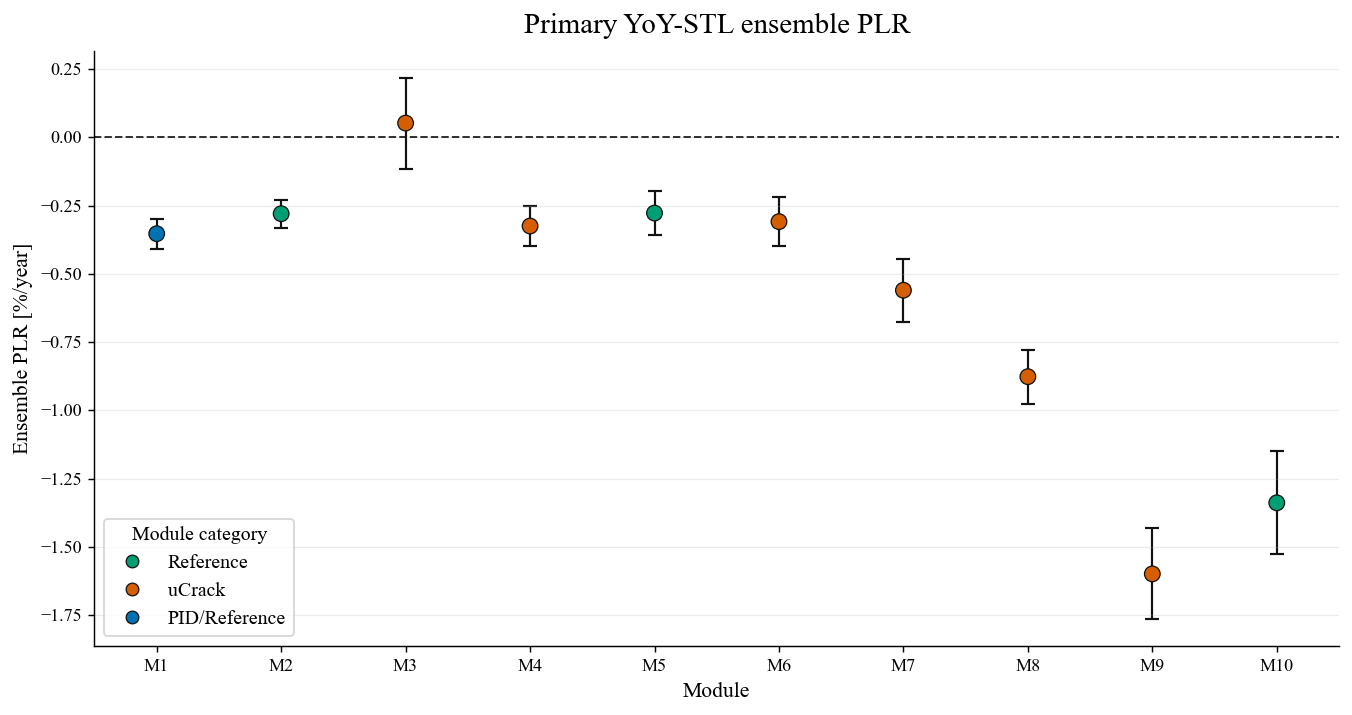

In [58]:
def plot_primary_ensemble_plr(
    primary_ensemble_main,
    save_name="fig_primary_yoy_stl_ensemble_plr.png",
):
    plot_df = primary_ensemble_main.sort_values("Module_ID").copy()

    x = plot_df["Module_ID"].astype(int).to_numpy()
    y = plot_df["PLR_ensemble_pct_per_year"].to_numpy()

    yerr_lower = y - plot_df["PLR_ensemble_ci_low"].to_numpy()
    yerr_upper = plot_df["PLR_ensemble_ci_high"].to_numpy() - y

    colors = plot_df["Type"].map(TYPE_COLORS).to_list()

    fig, ax = plt.subplots(figsize=(10.5, 5.6))

    ax.errorbar(
        x,
        y,
        yerr=[yerr_lower, yerr_upper],
        fmt="none",
        ecolor=BLACK,
        elinewidth=1.2,
        capsize=4,
        capthick=1.2,
        zorder=1,
    )

    ax.scatter(
        x,
        y,
        s=75,
        c=colors,
        edgecolor=BLACK,
        linewidth=0.7,
        zorder=2,
    )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Ensemble PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Primary YoY-STL ensemble PLR",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        handles=module_category_legend_handles(),
        title="Module category",
        loc="lower left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_primary_ensemble_plr(primary_ensemble_main)

## 12. Plot method-specific PLR estimates and primary ensemble

This figure compares the individual method-specific PLR estimates with the primary YoY-STL ensemble. It is used to assess method agreement and identify modules where the ensemble hides substantial method spread.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\fig_method_specific_plr_and_primary_ensemble.png


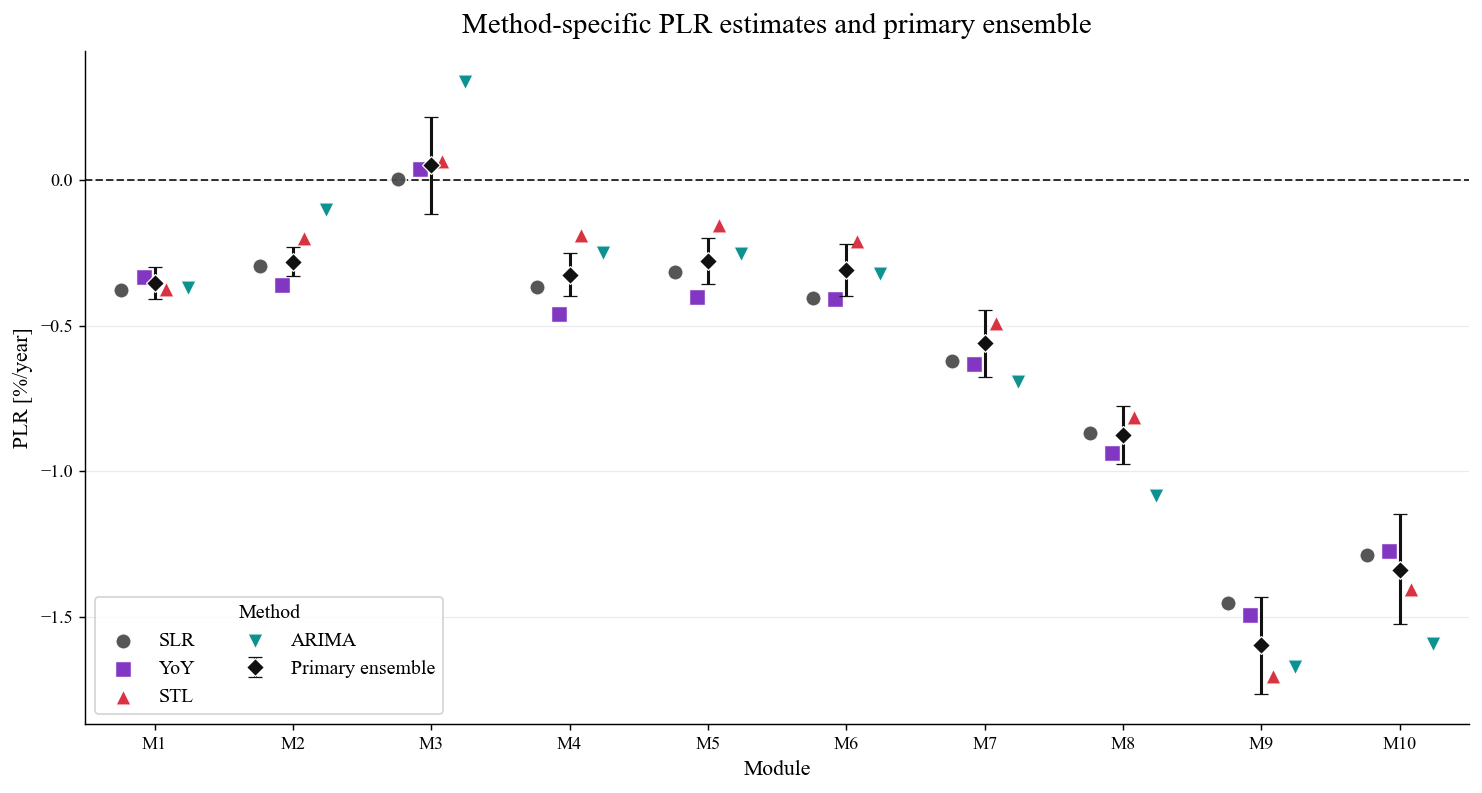

In [59]:
def plot_method_specific_estimates_and_primary_ensemble(
    method_results,
    primary_ensemble_main,
    save_name="fig_method_specific_plr_and_primary_ensemble.png",
):
    main_methods_plot = (
        method_results
        .loc[
            (method_results["dataset"] == MAIN_DATASET)
            & (method_results["method"].isin(["SLR", "YoY", "STL", "ARIMA"]))
        ]
        .copy()
    )

    ensemble_plot = primary_ensemble_main.copy()

    method_order = ["SLR", "YoY", "STL", "ARIMA"]

    method_offsets = {
        "SLR": -0.24,
        "YoY": -0.08,
        "STL": 0.08,
        "ARIMA": 0.24,
    }

    fig, ax = plt.subplots(figsize=(11.5, 6.2))

    for method_name in method_order:
        subset = main_methods_plot.loc[
            main_methods_plot["method"] == method_name
        ].copy()

        ax.scatter(
            subset["Module_ID"] + method_offsets[method_name],
            subset["PLR_pct_per_year"],
            s=72,
            marker=METHOD_MARKERS[method_name],
            color=METHOD_COLORS[method_name],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.95,
            label=method_name,
            zorder=3,
        )

    for _, row in ensemble_plot.iterrows():
        x = row["Module_ID"]
        y = row["PLR_ensemble_pct_per_year"]
        yerr_lower = y - row["PLR_ensemble_ci_low"]
        yerr_upper = row["PLR_ensemble_ci_high"] - y

        ax.errorbar(
            x,
            y,
            yerr=[[yerr_lower], [yerr_upper]],
            fmt="D",
            color=BLACK,
            ecolor=BLACK,
            elinewidth=1.7,
            capsize=4,
            capthick=1.7,
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=0.7,
            label="Primary ensemble" if row["Module_ID"] == ensemble_plot["Module_ID"].min() else None,
            zorder=5,
        )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("PLR [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Method-specific PLR estimates and primary ensemble",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Method",
        loc="lower left",
        frameon=True,
        ncol=2,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_method_specific_estimates_and_primary_ensemble(
    method_results=method_results,
    primary_ensemble_main=primary_ensemble_main,
)

## 13. Plot sensitivity ensemble shifts

This figure shows how much each sensitivity ensemble shifts relative to the primary YoY-STL ensemble. Values close to zero indicate that the headline ensemble is stable when SLR and/or ARIMA are added.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\fig_sensitivity_ensemble_shifts_relative_to_primary.png


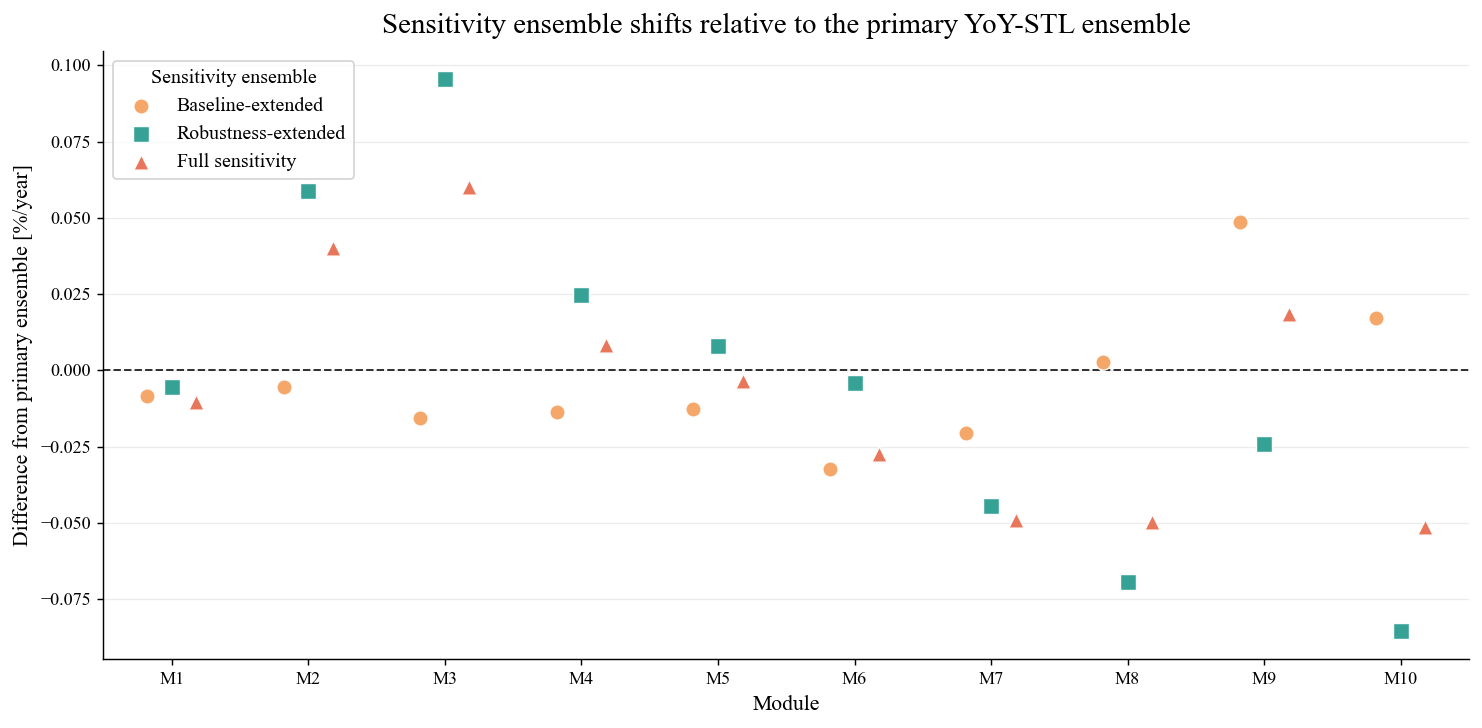

In [60]:
def plot_sensitivity_ensemble_shifts(
    ensemble_sensitivity_comparison,
    save_name="fig_sensitivity_ensemble_shifts_relative_to_primary.png",
):
    shift_df = (
        ensemble_sensitivity_comparison
        .loc[ensemble_sensitivity_comparison["ensemble"] != "Primary ensemble"]
        .copy()
        .sort_values(["Module_ID", "ensemble"])
    )

    sensitivity_order = [
        "Baseline-extended ensemble",
        "Robustness-extended ensemble",
        "Full sensitivity ensemble",
    ]

    sensitivity_offsets = {
        "Baseline-extended ensemble": -0.18,
        "Robustness-extended ensemble": 0.00,
        "Full sensitivity ensemble": 0.18,
    }

    sensitivity_markers = {
        "Baseline-extended ensemble": "o",
        "Robustness-extended ensemble": "s",
        "Full sensitivity ensemble": "^",
    }

    fig, ax = plt.subplots(figsize=(11.5, 5.7))

    for ensemble_name in sensitivity_order:
        subset = shift_df.loc[
            shift_df["ensemble"] == ensemble_name
        ].copy()

        ax.scatter(
            subset["Module_ID"] + sensitivity_offsets[ensemble_name],
            subset["PLR_difference_from_primary"],
            s=72,
            marker=sensitivity_markers[ensemble_name],
            color=METHOD_COLORS[ensemble_name],
            edgecolor="white",
            linewidth=0.8,
            alpha=0.95,
            label=ensemble_name.replace(" ensemble", ""),
            zorder=3,
        )

    ax.axhline(
        0,
        color=BLACK,
        linestyle="--",
        linewidth=1.1,
        alpha=0.85,
    )

    ax.set_xlim(0.5, 10.5)
    ax.set_xticks(range(1, 11))
    ax.set_xticklabels([f"M{i}" for i in range(1, 11)])

    ax.set_xlabel("Module", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Difference from primary ensemble [%/year]", fontsize=AXIS_LABEL_SIZE)

    ax.set_title(
        "Sensitivity ensemble shifts relative to the primary YoY-STL ensemble",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Sensitivity ensemble",
        loc="upper left",
        frameon=True,
        fontsize=LEGEND_SIZE,
        title_fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_sensitivity_ensemble_shifts(ensemble_sensitivity_comparison)

## 14. Save ensemble outputs

The final ensemble tables, method-comparison tables, and sensitivity outputs are saved for use in the results chapter.

In [61]:
method_results.to_csv(
    FINAL_TABLE_DIR / "ensemble_method_results_standardised.csv",
    index=False,
)

ensemble_results.to_csv(
    FINAL_TABLE_DIR / "ensemble_all_results.csv",
    index=False,
)

primary_ensemble_main.to_csv(
    FINAL_TABLE_DIR / "primary_yoy_stl_ensemble_g200.csv",
    index=False,
)

ensemble_sensitivity_comparison.to_csv(
    FINAL_TABLE_DIR / "ensemble_sensitivity_comparison_g200.csv",
    index=False,
)

ensemble_sensitivity_summary.to_csv(
    FINAL_TABLE_DIR / "ensemble_sensitivity_summary_g200.csv",
    index=False,
)

method_support_summary.to_csv(
    FINAL_TABLE_DIR / "ensemble_method_support_summary.csv",
    index=False,
)

final_plr_report_table_display.to_csv(
    FINAL_TABLE_DIR / "plr_method_and_primary_ensemble_report_table_g200.csv",
    index=False,
)

final_plr_report_table_numeric.to_csv(
    FINAL_TABLE_DIR / "plr_method_and_primary_ensemble_numeric_table_g200.csv",
    index=False,
)

method_results.to_parquet(
    ENSEMBLE_OUTPUT_DIR / "ensemble_method_results_standardised.parquet",
    index=False,
)

ensemble_results.to_parquet(
    ENSEMBLE_OUTPUT_DIR / "ensemble_all_results.parquet",
    index=False,
)

primary_ensemble_main.to_parquet(
    ENSEMBLE_OUTPUT_DIR / "primary_yoy_stl_ensemble_g200.parquet",
    index=False,
)

final_plr_report_table_numeric.to_parquet(
    ENSEMBLE_OUTPUT_DIR / "plr_method_and_primary_ensemble_numeric_table_g200.parquet",
    index=False,
)

print("Saved ensemble outputs.")

Saved ensemble outputs.
